# Метод Ньютона для нахождения корней уравнения

Реализация метода Ньютона для решения уравнения f(x) = 0.
Метод Ньютона — итерационный метод с локальной квадратичной сходимостью около простого корня при достаточной гладкости функции.

Итерационная формула: $x_{n+1}=x_n-f(x_n)/f'(x_n)$.

Преимущества метода Ньютона:
- Квадратичная сходимость вблизи корня
- Быстрая сходимость при хорошем начальном приближении

Недостатки:
- Требует вычисления производной
- Может расходиться при плохом начальном приближении
- Чувствителен к кратным корням

In [3]:
import numpy as np
import matplotlib.pyplot as plt

MAX_ITER = 100
TOL = 1e-10
MAX_FUNC_VALUE = 1e10

## Основная функция метода

Успех проверяем по модулю невязки. Проверка выполняется до деления на производную, в том числе для начального приближения и после последнего разрешённого шага.

In [4]:
def newton_method(f, df, x0, max_iter=MAX_ITER, tol=TOL):
    """Возвращает последнее приближение, историю и флаг достижения допуска невязки."""
    x = np.float64(x0)
    iterations = [float(x)]

    for i in range(max_iter + 1):
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            fx = f(x)
        if not np.isfinite(fx) or abs(fx) > MAX_FUNC_VALUE:
            print(f"Остановка: недопустимое значение функции на шаге {i}")
            break
        if abs(fx) <= tol:
            return float(x), iterations, True
        if i == max_iter:
            break

        dfx = df(x)
        if not np.isfinite(dfx) or abs(dfx) < 1e-14:
            print(f"Остановка: производная близка к нулю или неконечна на шаге {i}")
            break

        x_new = x - fx / dfx
        if not np.isfinite(x_new):
            print(f"Остановка: неконечное приближение на шаге {i+1}")
            break
        iterations.append(float(x_new))
        x = x_new

    return float(x), iterations, False

## Графики для анализа сходимости

Сохраним четыре панели исходного примера: геометрия касательных, последовательность приближений, ошибка относительно известного корня и невязка. Для читаемости на первой панели показаны не более шести шагов.

In [5]:
def plot_convergence_analysis(f, df, x0, x_true=None, title="Анализ сходимости метода Ньютона", max_iter=MAX_ITER):
    """
    Создание графиков для анализа сходимости метода Ньютона

    Args:
        f: функция f(x)
        df: производная f'(x)
        x0: начальное приближение
        x_true: истинное значение корня (если известно)
        title: заголовок графика
    """
    # Запуск метода Ньютона
    root, iterations, converged = newton_method(f, df, x0, max_iter=max_iter)

    print(f"Результат метода Ньютона:")
    print(f"Начальное приближение: x0 = {x0}")
    print(f"Последнее приближение: x = {root:.10f}")
    print(f"Количество итераций: {len(iterations)-1}")
    print(f"Сошелся: {converged}")

    if x_true is not None:
        error = abs(root - x_true)
        print(f"Истинная ошибка: |x - x_true| = {error:.2e}")

        # Вычисление ошибок на каждой итерации
        errors = [abs(x - x_true) for x in iterations]

    # Создаем фигуру с подграфиками
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14)

    # Подграфик 1: График функции и итераций метода Ньютона
    x_plot = np.linspace(min(iterations + ([x_true] if x_true is not None else [])) - 0.5, max(iterations + ([x_true] if x_true is not None else [])) + 0.5, 1000)
    y_plot = f(x_plot)

    axes[0,0].plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    axes[0,0].axhline(y=0, color='k', linestyle='--', alpha=0.5, label='y=0')

    # Отмечаем начальное приближение
    axes[0,0].plot(x0, f(x0), 'ro', markersize=8, label=f'Начальное приближение x0={x0:.3f}')

    # Отмечаем найденный корень
    axes[0,0].plot(root, f(root), 'go' if converged else 'mo', markersize=8,
                   label=f'Последнее приближение x={root:.6f}')

    # Показываем итерационный процесс
    for i in range(min(len(iterations)-1, 6)):
        x_curr = iterations[i]
        x_next = iterations[i+1]
        axes[0,0].plot([x_curr, x_curr], [0, f(x_curr)], 'r--', alpha=0.7)
        axes[0,0].plot([x_curr, x_next], [f(x_curr), 0], 'r--', alpha=0.7)

    axes[0,0].set_xlabel('x')
    axes[0,0].set_ylabel('f(x)')
    axes[0,0].set_title('График функции и итераций метода Ньютона')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Подграфик 2: Последовательность приближений x_n
    iter_nums = list(range(len(iterations)))
    axes[0,1].plot(iter_nums, iterations, 'b-o', linewidth=2, markersize=6, label='x_n')
    if x_true is not None:
        axes[0,1].axhline(y=x_true, color='g', linestyle='--', label=f'Истинный корень x={x_true:.6f}')
    axes[0,1].set_xlabel('Номер итерации')
    axes[0,1].set_ylabel('x_n')
    axes[0,1].set_title('Последовательность приближений x_n')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Подграфик 3: График ошибки сходимости (если известен истинный корень)
    if x_true is not None:
        errors = [abs(x - x_true) for x in iterations]
        axes[1,0].semilogy(iter_nums, np.where(np.array(errors) > 0, errors, np.nan), 'r-o', linewidth=2, markersize=6, label='|x_n - x_true|')
        axes[1,0].set_xlabel('Номер итерации')
        axes[1,0].set_ylabel('|x_n - x_true| (лог. шкала)')
        axes[1,0].set_title('График ошибки сходимости')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
    else:
        axes[1,0].text(0.5, 0.5, 'Истинный корень\nне известен',
                      transform=axes[1,0].transAxes, ha='center', va='center',
                      fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
        axes[1,0].set_title('График ошибки сходимости (недоступен)')

    # Подграфик 4: График f(x_n) - проверка достижения нуля
    f_values = [abs(f(x)) for x in iterations]
    axes[1,1].semilogy(iter_nums, np.where(np.array(f_values) > 0, f_values, np.nan), 'm-o', linewidth=2, markersize=6, label='|f(x_n)|')
    axes[1,1].axhline(y=TOL, color='k', linestyle='--', label=f'Допуск невязки {TOL}')
    axes[1,1].set_xlabel('Номер итерации')
    axes[1,1].set_ylabel('|f(x_n)| (лог. шкала)')
    axes[1,1].set_title('Проверка f(x_n) → 0')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return root, iterations, converged

## Пример 1: полиномиальная функция $x^3-2x-5=0$

Возьмём $x_0=2$. Здесь функция, подписи и известное значение корня относятся к одному уравнению.

Результат метода Ньютона:
Начальное приближение: x0 = 2.0
Последнее приближение: x = 2.0945514815
Количество итераций: 4
Сошелся: True
Истинная ошибка: |x - x_true| = 4.44e-16


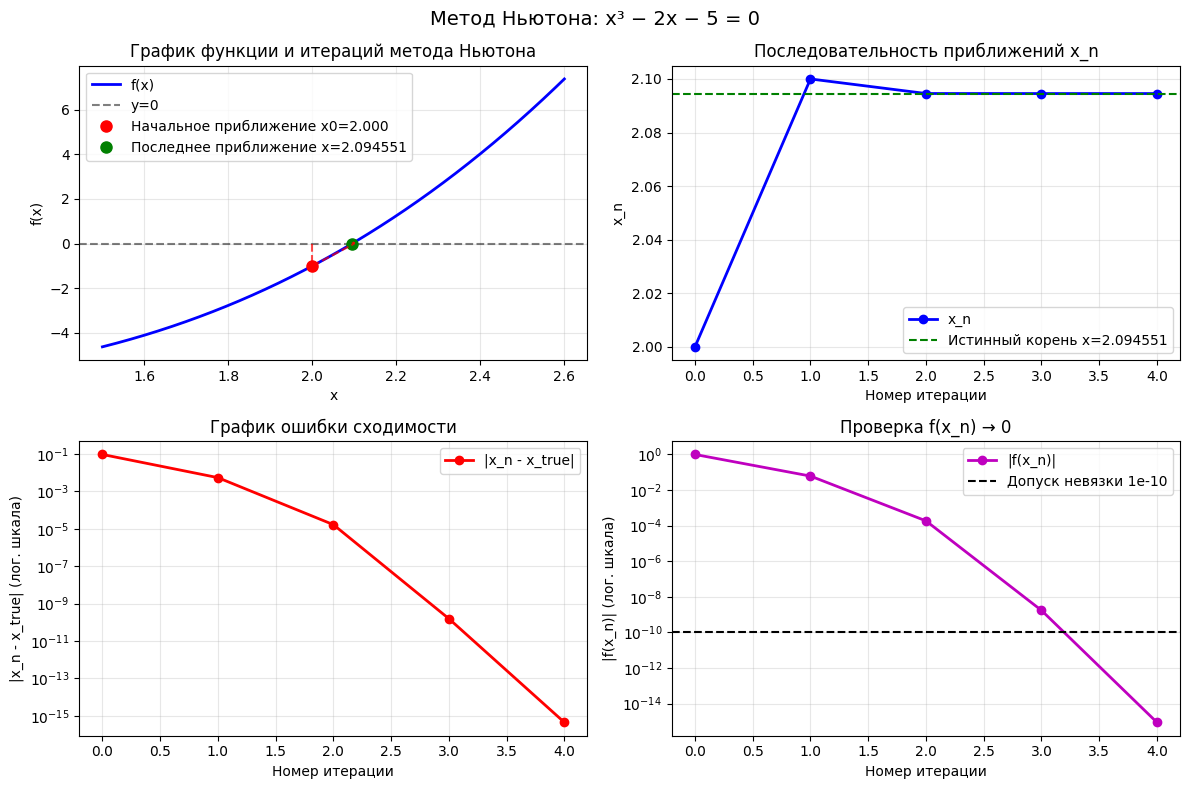

In [6]:
def f1(x):
    return x**3 - 2*x - 5


def df1(x):
    return 3*x**2 - 2


x_true_1 = 2.094551481542327
root_1, history_1, converged_1 = plot_convergence_analysis(
    f1, df1, x0=2.0, x_true=x_true_1, title="Метод Ньютона: x³ − 2x − 5 = 0")

## Пример 2: устойчивый цикл вместо корня

В исходном скрипте также использовалась функция $f(x)=x^3-2x+2$. Рассмотрим её отдельно, начиная с $x_0=0.1$.

Для отображения $G(x)=x-f(x)/f'(x)$ легко проверить $G(0)=1$, $G(1)=0$. Поэтому последовательность может приближаться к циклу $0\leftrightarrow1$, хотя ни одна из этих точек не является корнем. Ограничим демонстрацию двенадцатью шагами.

Результат метода Ньютона:
Начальное приближение: x0 = 0
Последнее приближение: x = 0.0000000000
Количество итераций: 12
Сошелся: False
Истинная ошибка: |x - x_true| = 1.77e+00


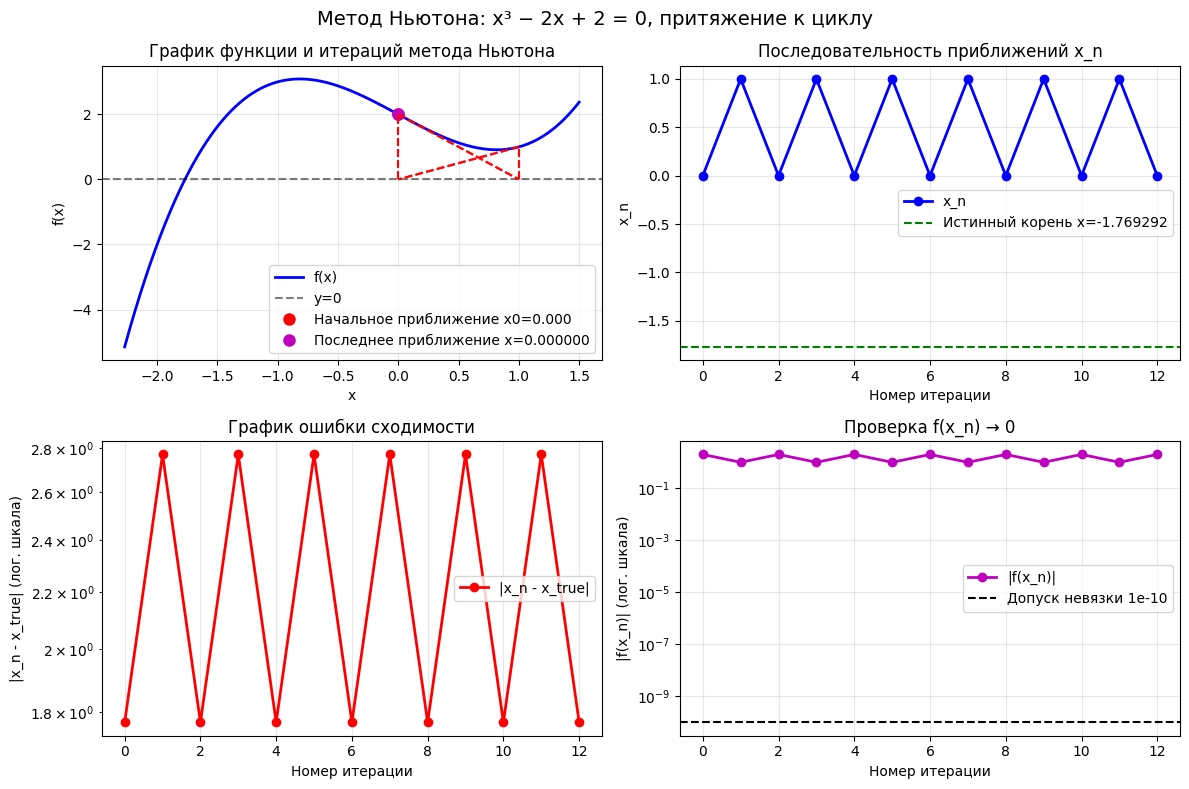

In [7]:
def f_cycle(x):
    return x**3 - 2*x + 2


def df_cycle(x):
    return 3*x**2 - 2


roots_cycle = np.roots([1.0, 0.0, -2.0, 2.0])
x_true_cycle = roots_cycle[np.abs(roots_cycle.imag) < 1e-12][0].real
root_cycle, history_cycle, converged_cycle = plot_convergence_analysis(
    f_cycle, df_cycle, x0=0, x_true=x_true_cycle,
    title="Метод Ньютона: x³ − 2x + 2 = 0, притяжение к циклу", max_iter=12)

## Анализ результатов метода Ньютона

### Преимущества метода Ньютона:
1. **Квадратичная сходимость**: Вблизи простого корня ошибка уменьшается квадратично при достаточной гладкости функции
2. **Быстрая сходимость**: Обычно сходится за 5-10 итераций при хорошем начальном приближении
3. **Высокая точность**: Может достигать машинной точности

### Недостатки метода Ньютона:
1. **Требует производной**: Нужно вычислять f'(x) аналитически или приближённо
2. **Чувствителен к начальным условиям**: Может расходиться при плохом x0
3. **Проблемы с кратными корнями**: Для кратных корней сходимость ухудшается

### Практические рекомендации:
- Выбирайте начальное приближение близко к ожидаемому корню
- Проверяйте значение производной на каждой итерации
- Используйте защиту от переполнения и деления на ноль
- Проверяйте невязку: малый шаг сам по себе не означает, что найден корень

### Графики сходимости показывают:
- Геометрическую интерпретацию метода (касательные к графику функции)
- Скорость убывания ошибки (квадратичная сходимость)
- Стабильность метода при различных начальных условиях

**Попробуйте:** для второго полинома взять $x_0=-2$; для $f(x)=\sin x$ — $x_0=3$. Сравните сходимость к корню и поведение около цикла.

В следующем ноутбуке рассмотрим те же итерации на комплексной плоскости: разные начальные точки могут притягиваться к разным корням или к циклу.